In [24]:
from lorenzo_utils import *
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

graph_path = DATA_DIR + 'Centrality/Centrality_climate_19.graphml'
G = load_graph(graph_path)



c:\Users\maria\Desktop\Analisi e visualizzazione reti complesse\AVRC_FinnishTwittersphereProject\Maru\lorenzo_utils.py:24: RuntimeWarning: Could not add vertex ids, there is already an 'id' vertex attribute. Location: src/io/graphml.c:434
  return ig.Graph.Read_GraphML(filename)


In [2]:
COMPUTE_CENTRALITY = False
if COMPUTE_CENTRALITY:
    from sys import stdout
    for graph_file in GRAPH_FILENAMES:
        print('loading:', graph_file)
        stdout.flush()
        G = load_graph(DATA_DIR + graph_file)
        load_all_centralities(G, dumpfile=DATA_DIR+'Centrality/Centrality_'+graph_file)
        print('saved centrality')

# CCDF (Complementary cumulative distribution)

In [3]:
def plot_ccdf(G: ig.Graph, metric: str='degree', log: bool=True):
    values = np.array(G.vs[metric])
    k_values, ccdf = compute_ccdf(values)
    kA_values, ccdfA = compute_ccdf(values[[group == 'A' for group in G.vs['group']]])
    kB_values, ccdfB = compute_ccdf(values[[group == 'B' for group in G.vs['group']]])

    fig, ax = plt.subplots(figsize=(6,4), sharex=True, layout='tight')
    ax.plot(k_values, ccdf, marker='.', linewidth='2', markersize='0.3', color = cmap(0), label='Tot')
    ax.plot(kA_values, ccdfA, marker='.', linewidth='2', markersize='0.3', color = cmap(1), label='A')
    ax.plot(kB_values, ccdfB, marker='.', linewidth='2', markersize='0.3', color = cmap(2), label='B')
    ax.set_title(metric + ' complementary cumulative distribution')
    ax.set_xlabel(metric)
    ax.set_ylabel('ccdf')
    fig.legend(frameon=False, bbox_to_anchor=(0.99,0.9), loc='upper right')
    if log:
        ax.set_xscale('log')
        ax.set_yscale('log')

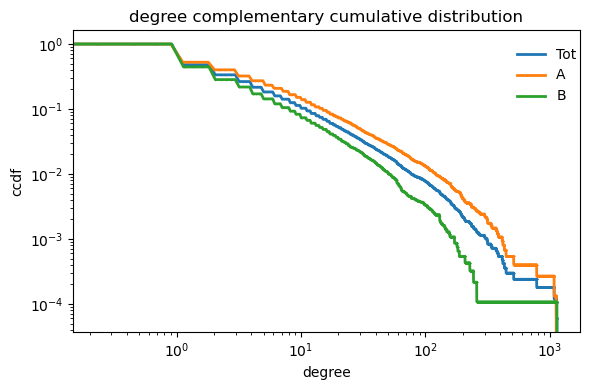

In [4]:
plot_ccdf(G, 'degree')

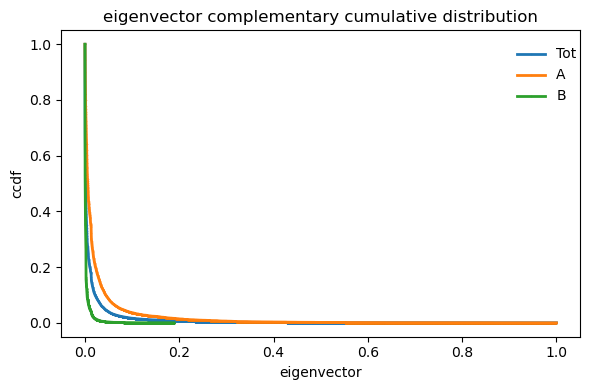

In [ ]:
plot_ccdf(G, 'eigenvector', log=True)

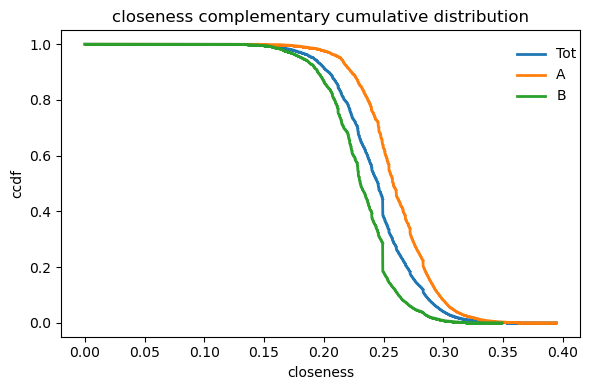

In [6]:
plot_ccdf(G, 'closeness', log=False)

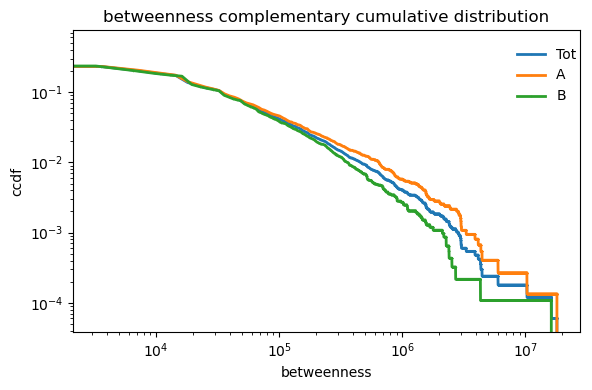

In [7]:
plot_ccdf(G, 'betweenness', log=True)

# Scatter plot

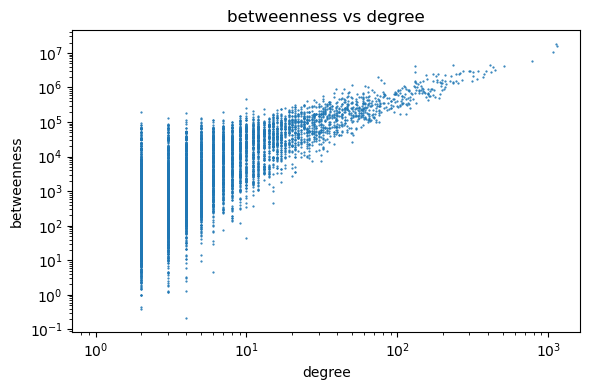

In [22]:
fig, ax = plt.subplots(figsize=(6,4), sharex=True, layout='tight')
ax.scatter(G.vs['degree'], G.vs['betweenness'], s=0.3, color=cmap(0))
ax.set_title('betweenness vs degree')
ax.set_xlabel('degree')
ax.set_ylabel('betweenness')
ax.set_xscale('log')
ax.set_yscale('log')

# Distribuzioni di misure di centralità

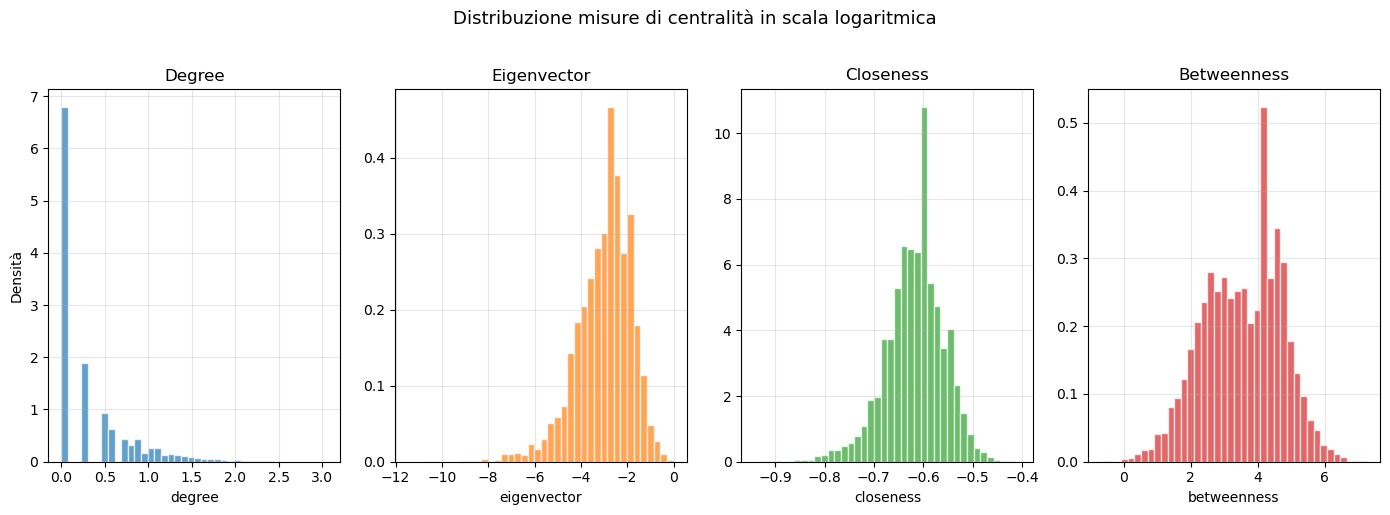

In [53]:
metrics = ['degree', 'eigenvector', 'closeness', 'betweenness']
fig, axes = plt.subplots(1, 4, figsize=(14, 5))
colors = [cmap(i) for i in range(len(metrics))]

for ax, m, color in zip(axes, metrics, colors):
    values = np.array(G.vs[m], dtype=float)
    values = values[values > 0]
    
    ax.hist(np.log10(values), bins=40, density=True,
            color=color, alpha=0.7, edgecolor='white')
    ax.set_title(m.capitalize())
    ax.set_xlabel(m)
    ax.set_ylabel("Densità" if ax == axes[0] else "")
    ax.grid(alpha=0.3)

fig.suptitle("Distribuzione misure di centralità in scala logaritmica", fontsize=13, y=1.02)
plt.tight_layout()